# Stage 2: Segmentation via Clustering (Refactored)

### Resolusi Kritis & Perbaikan Metodologi:
Berdasarkan hasil evaluasi auditor pada tahap sebelumnya, notebook ini telah dirombak untuk mengamankan validitas statistik:
1. **Pencegahan Double-Scaling:** Kami tidak lagi menggunakan `StandardScaler` di tahap ini karena data telah melalui normalisasi *Yeo-Johnson* di Stage 1.
2. **Filtrasi Dead Feature:** Kolom `customer_freq_normalized` di-*drop* dari *clustering feature space* karena variansinya telah mati (99.5% bernilai 1 akibat pembuangan data anomali KYC di Stage 1). Mengikutsertakan fitur ini hanya akan merusak perhitungan jarak Euclidean.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as shc
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

In [15]:
# ==========================================
# 1. LOAD AND PREPARE DATA (NO STANDARD SCALER)
# ==========================================
print("Loading datasets...")
# Pastikan path ini sesuai dengan folder di laptop lu
df = pd.read_csv('../../data/stage1_ETL/clean.csv') 
df_categorical = pd.read_csv('../../data/stage1_ETL/clean_categorical.csv') 

# FIX: Buang fitur 'customer_freq_normalized' karena variansinya sudah mati
features = [
    'age_ordinal_normalized', 
    'cust_account_balance_normalized', 
    'transaction_amount_inr_normalized'
]
df_cluster = df[features].dropna()

# FIX: LANGSUNG AMBIL DATANYA! Tidak perlu StandardScaler karena sudah dinormalisasi di Stage 1
X_scaled = df_cluster.values

# Ambil sampel 10.000 untuk komputasi berat agar RAM aman
SAMPLE_SIZE = 10000
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_indices]

Loading datasets...


In [16]:
# ==========================================
# 2. DETERMINE OPTIMAL K (PROGRAMMATIC)
# ==========================================
print("\nCalculating Elbow Method and Silhouette Scores (on sample)...")
wcss = []
sil_scores = []
k_range = list(range(2, 8))

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sample_preds = kmeans.predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, sample_preds))

# FIX: Programmatic Elbow & Silhouette (Otomatis nyari angka K terbaik)
kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
elbow_k = kl.elbow if kl.elbow else 3

practical_scores = {k: s for k, s in zip(k_range, sil_scores) if 2 <= k <= 5}
OPTIMAL_K = max(practical_scores, key=practical_scores.get)
print(f"Programmatic selection: OPTIMAL_K = {OPTIMAL_K} (Silhouette = {practical_scores[OPTIMAL_K]:.4f})")


Calculating Elbow Method and Silhouette Scores (on sample)...
Programmatic selection: OPTIMAL_K = 2 (Silhouette = 0.2802)


In [17]:
# ==========================================
# 3. APPLY K-MEANS CLUSTERING
# ==========================================
print(f"\nApplying K-Means with K={OPTIMAL_K} on full dataset...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df_cluster['Cluster_Labels'] = kmeans_final.fit_predict(X_scaled)


Applying K-Means with K=2 on full dataset...



Generating Dendrograms (Ward Linkage)...
Saved 'dendrogram_ward_fixed.png'.


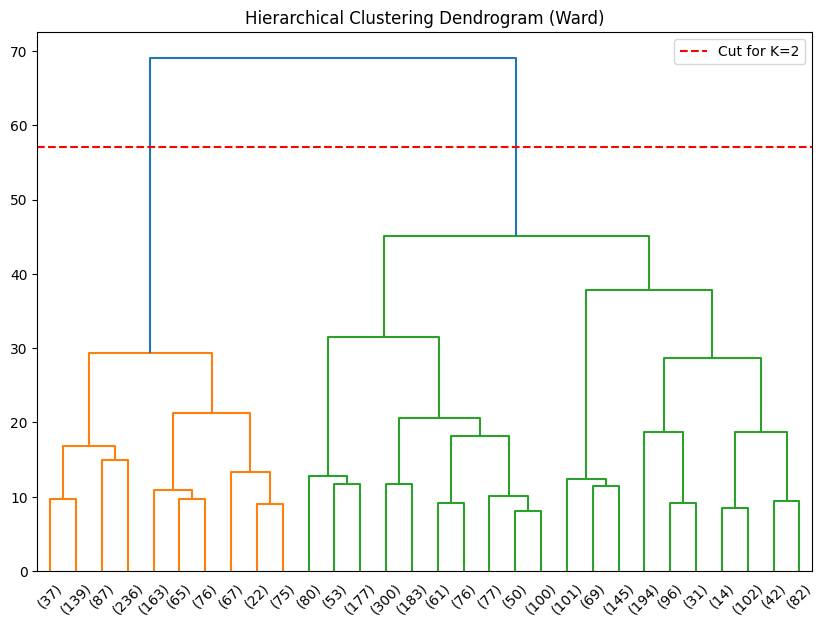

In [18]:
# ==========================================
# 4. HIERARCHICAL CLUSTERING & DENDROGRAMS
# ==========================================
print("\nGenerating Dendrograms (Ward Linkage)...")
np.random.seed(42)  # FIX: Seed untuk reproducibility grafik
X_dendro_sample = X_scaled[np.random.choice(X_scaled.shape[0], 3000, replace=False)]

Z = shc.linkage(X_dendro_sample, method='ward')
n_merges = Z.shape[0]
cut_height = (Z[-(OPTIMAL_K - 1), 2] + Z[-OPTIMAL_K, 2]) / 2 if 2 <= OPTIMAL_K <= n_merges else Z[-2, 2] * 0.7 

plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward)")
shc.dendrogram(Z, truncate_mode='lastp', p=30)
plt.axhline(y=cut_height, color='r', linestyle='--', label=f'Cut for K={OPTIMAL_K}')
plt.legend()
plt.savefig('dendrogram_ward_fixed.png')
print("Saved 'dendrogram_ward_fixed.png'.")

In [19]:
# ==========================================
# 5. DBSCAN (EMPIRICAL EPS SELECTION)
# ==========================================
print("\nApplying DBSCAN: computing k-distance graph for empirical eps...")
k_neighbors = 2 * X_sample.shape[1]
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_distances = np.sort(distances[:, -1])[::-1]

# FIX: Mencari angka eps otomatis secara matematis
kl_dbscan = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='decreasing')
optimal_eps = k_distances[kl_dbscan.knee] if kl_dbscan.knee else 0.5
print(f"Empirical optimal eps derived: {optimal_eps:.4f}")

dbscan = DBSCAN(eps=optimal_eps, min_samples=k_neighbors)
db_labels = dbscan.fit_predict(X_sample)
outliers_count = (db_labels == -1).sum()
print(f"DBSCAN found {outliers_count} noise/outlier points.")


Applying DBSCAN: computing k-distance graph for empirical eps...
Empirical optimal eps derived: 0.5653
DBSCAN found 107 noise/outlier points.


In [20]:
# ==========================================
# 6. DELIVERABLE: THE MERGE STRATEGY (100% REAL RUPEE VALUES)
# ==========================================
print("\n==========================================")
print("FINAL CLUSTER PROFILES (TRUE ORIGINAL SCALE)")
print("==========================================")

# FIX: Langsung hubungkan label klaster ke data angka asli di clean_categorical.csv!
original_cols = ['age', 'cust_account_balance', 'transaction_amount_inr']

df_merged = pd.DataFrame(index=df_cluster.index)
df_merged['Cluster_Labels'] = df_cluster['Cluster_Labels'].values

for orig_col in original_cols:
    if orig_col in df_categorical.columns:
        df_merged[orig_col] = df_categorical[orig_col].iloc[df_cluster.index].values

# Sekarang rata-rata yang keluar adalah RUPIAH (INR) murni dan UMUR murni
cluster_profiles_real = df_merged.groupby('Cluster_Labels')[original_cols].mean().round(2)
cluster_profiles_real['Customer_Count'] = df_merged['Cluster_Labels'].value_counts()

print(cluster_profiles_real)
cluster_profiles_real.to_csv('cluster_business_profiles_REAL_fixed.csv')
print("\nExported 'cluster_business_profiles_REAL_fixed.csv'")


FINAL CLUSTER PROFILES (TRUE ORIGINAL SCALE)
                  age  cust_account_balance  transaction_amount_inr  \
Cluster_Labels                                                        
0               35.19             198216.55                 2578.88   
1               26.41              16272.05                  375.53   

                Customer_Count  
Cluster_Labels                  
0                       342416  
1                       356845  

Exported 'cluster_business_profiles_REAL_fixed.csv'
